# 导入库

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve
)
import joblib

sns.set_style('whitegrid')
plt.rcParams['font.sans-serif'] = ['Heiti TC', 'Songti SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
RANDOM_STATE = 42

# 加载数据&初步检查

In [5]:
df = pd.read_excel('/Users/mys/Desktop/Github/Bank-Churn-Prediction/BankCustomer.xlsx')
print(f"数据规模: {df.shape}")
df.head()

数据规模: (10000, 12)


,Name,Gender,Age,City,Tenure,ProductsNo,HasCard,ActiveMember,Credit,AccountBal,Salary,Exited
0,Kan Jian,Female,40,Beijing,9,2,0,1,516,6360.66,0.0000,0
1,Xue Baochai,Male,69,Beijing,6,2,0,1,682,28605.00,0.0000,0
2,Mao Xi,Female,32,Beijing,9,1,1,1,803,10378.09,236311.0932,1
3,Zheng Nengliang,Female,37,Tianjin,0,2,1,1,778,25564.01,129909.8079,1
4,Zhi Fen,Male,55,Tianjin,4,3,1,0,547,3235.61,136976.1948,1


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          10000 non-null  str    
 1   Gender        10000 non-null  str    
 2   Age           10000 non-null  int64  
 3   City          10000 non-null  str    
 4   Tenure        10000 non-null  int64  
 5   ProductsNo    10000 non-null  int64  
 6   HasCard       10000 non-null  int64  
 7   ActiveMember  10000 non-null  int64  
 8   Credit        10000 non-null  int64  
 9   AccountBal    10000 non-null  float64
 10  Salary        10000 non-null  float64
 11  Exited        10000 non-null  int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 1.1 MB


In [7]:
print("缺失值：")
print(df.isna().sum())
print(f"\n重复行数: {df.duplicated().sum()}")

缺失值：
Name            0
Gender          0
Age             0
City            0
Tenure          0
ProductsNo      0
HasCard         0
ActiveMember    0
Credit          0
AccountBal      0
Salary          0
Exited          0
dtype: int64

重复行数: 0


# EDA

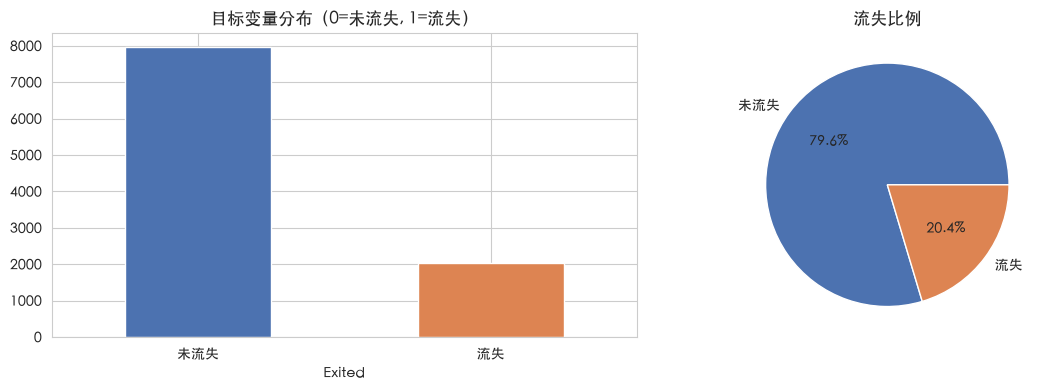

流失率: 20.37%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["Exited"].value_counts().plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("目标变量分布（0=未流失, 1=流失）")
axes[0].set_xticklabels(["未流失", "流失"], rotation=0)

df["Exited"].value_counts(normalize=True).plot(
    kind="pie",
    ax=axes[1],
    autopct="%.1f%%",
    labels=["未流失", "流失"],
    colors=["#4C72B0", "#DD8452"],
)
axes[1].set_title("流失比例")

plt.tight_layout()
plt.show()

print(f"流失率: {df['Exited'].mean()*100:.2f}%")

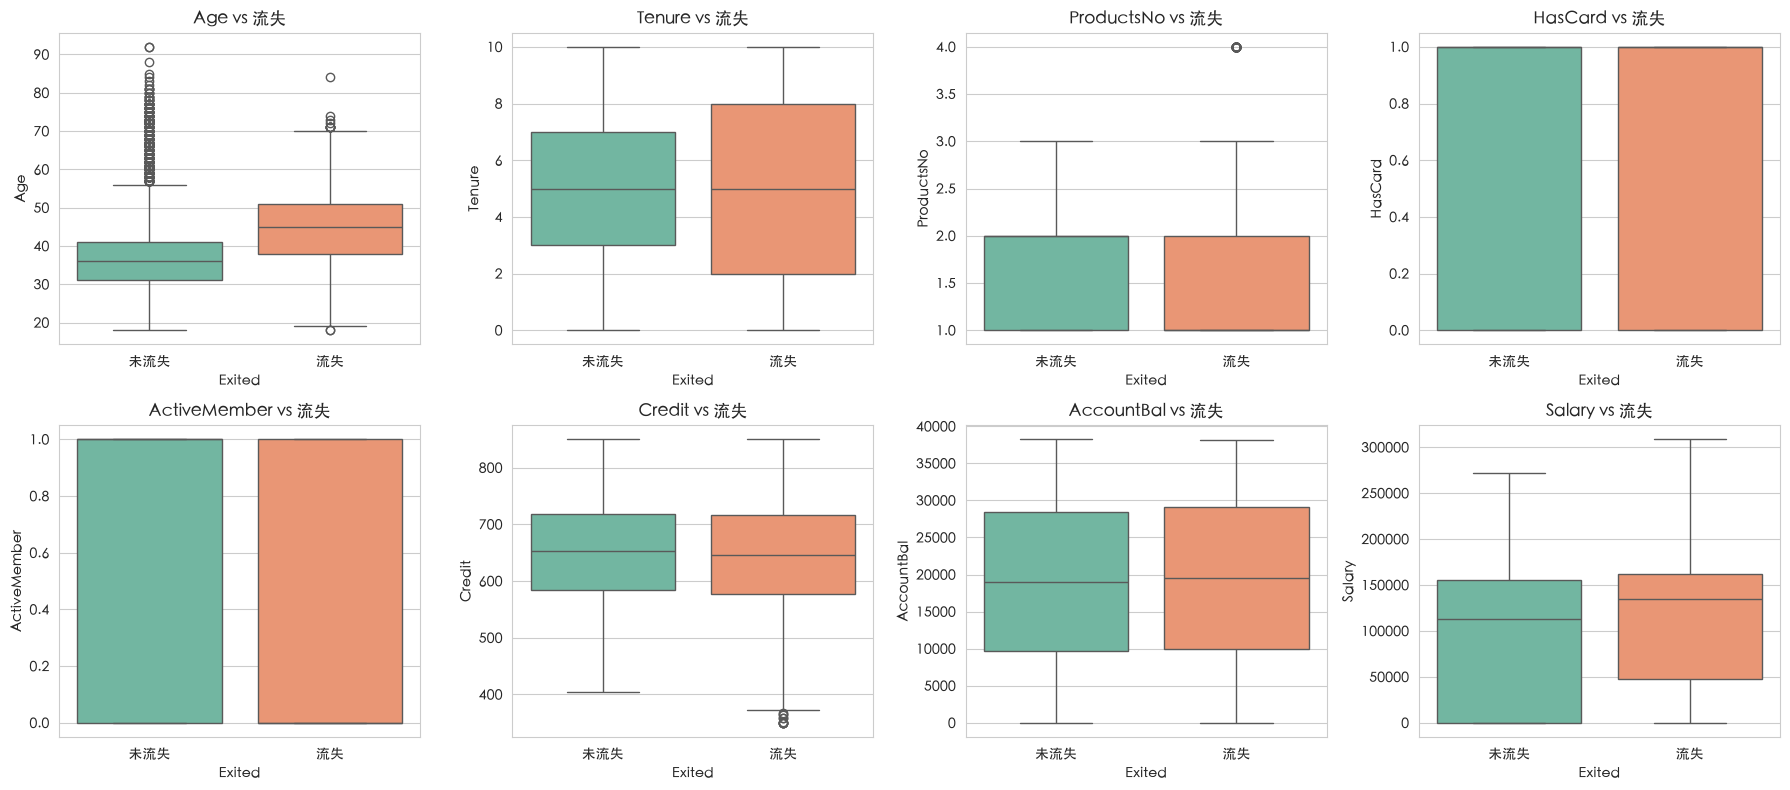

In [9]:
num_cols = [
    "Age",
    "Tenure",
    "ProductsNo",
    "HasCard",
    "ActiveMember",
    "Credit",
    "AccountBal",
    "Salary",
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, col in enumerate(num_cols):
    sns.boxplot(x="Exited", y=col, data=df, ax=axes[i // 4, i % 4], palette="Set2")
    axes[i // 4, i % 4].set_title(f"{col} vs 流失")
    axes[i // 4, i % 4].set_xticklabels(["未流失", "流失"])
plt.tight_layout()
plt.show()

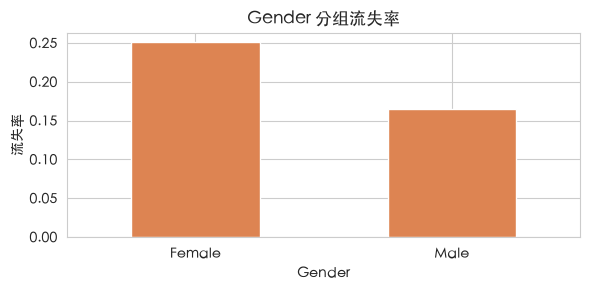


Gender 分组流失率:
Gender
Female    0.250715
Male      0.164559
Name: Exited, dtype: float64



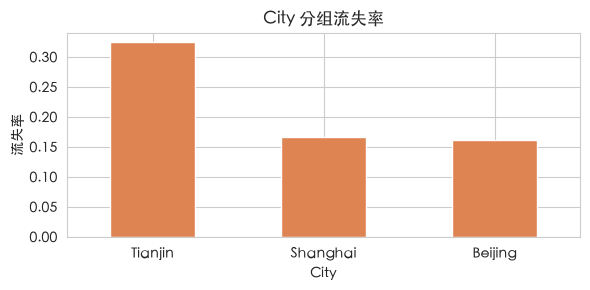


City 分组流失率:
City
Tianjin     0.324432
Shanghai    0.166734
Beijing     0.161548
Name: Exited, dtype: float64



In [10]:
for col in ['Gender', 'City']:
    rate = df.groupby(col)['Exited'].mean().sort_values(ascending=False)
    plt.figure(figsize=(6, 3))
    rate.plot(kind='bar', color='#DD8452')
    plt.title(f'{col} 分组流失率')
    plt.ylabel('流失率')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
    print(f"\n{col} 分组流失率:\n{rate}\n")

# 数据预处理

In [11]:
df = df.drop('Name', axis=1)

df = pd.get_dummies(df, columns=['City'], drop_first=True, dtype=int)

enc = OrdinalEncoder()
df['Gender'] = enc.fit_transform(df[['Gender']])

print(f"编码后数据规模: {df.shape}")
print(f"列名: \n{df.columns.tolist()}")

编码后数据规模: (10000, 12)
列名: 
['Gender', 'Age', 'Tenure', 'ProductsNo', 'HasCard', 'ActiveMember', 'Credit', 'AccountBal', 'Salary', 'Exited', 'City_Shanghai', 'City_Tianjin']


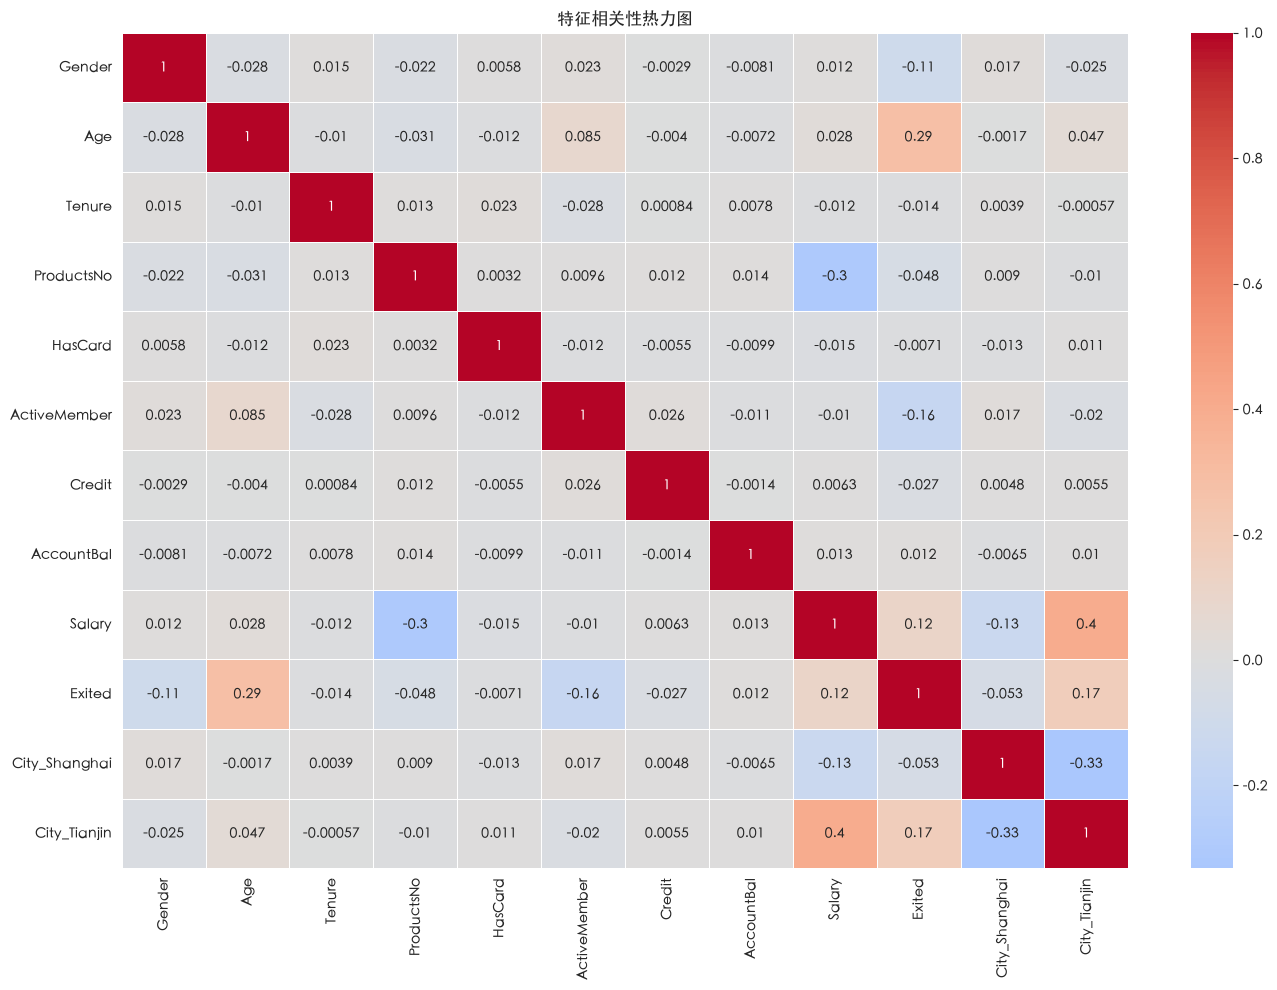

In [12]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=True,center=0, linewidths=0.5)
plt.title('特征相关性热力图')
plt.tight_layout()
plt.show()

# 划分数据集

In [13]:
y = df['Exited']
X = df.drop('Exited', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"训练集: {X_train.shape}, 测试集: {X_test.shape}")
print(f"训练集流失率: {np.round(y_train.mean()*100,2)}%")
print(f"测试集流失率: {np.round(y_test.mean()*100,2)}%")

训练集: (8000, 11), 测试集: (2000, 11)
训练集流失率: 20.38%
测试集流失率: 20.35%


# 基线模型（未处理不平衡 + 无标准化）对比

In [14]:
lr_base = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr_base.fit(X_train, y_train)

y_proba_base = lr_base.predict_proba(X_test)[:, 1] 
y_pred_base = lr_base.predict(X_test)

print("【基线逻辑回归（未处理不平衡，未标准化）】")
print(f"AUC: {roc_auc_score(y_test, y_proba_base):.3f}")
print(classification_report(y_test, y_pred_base))

【基线逻辑回归（未处理不平衡，未标准化）】
AUC: 0.739
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.18      0.27       407

    accuracy                           0.81      2000
   macro avg       0.70      0.57      0.58      2000
weighted avg       0.77      0.81      0.76      2000



# 改进模型 1：Pipeline + class_weight

In [15]:
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

pipe_lr.fit(X_train, y_train)

y_proba_lr = pipe_lr.predict_proba(X_test)[:, 1]
y_pred_lr = pipe_lr.predict(X_test)

print("【改进版：Pipeline + 标准化 + class_weight】")
print(f"AUC: {roc_auc_score(y_test, y_proba_lr):.3f}")
print(classification_report(y_test, y_pred_lr))

【改进版：Pipeline + 标准化 + class_weight】
AUC: 0.761
              precision    recall  f1-score   support

           0       0.89      0.72      0.80      1593
           1       0.38      0.65      0.48       407

    accuracy                           0.71      2000
   macro avg       0.63      0.69      0.64      2000
weighted avg       0.79      0.71      0.73      2000



# 改进模型 2：随机森林对比

In [16]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_proba_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf = rf.predict(X_test)

print("【随机森林（balanced）】")
print(f"AUC: {roc_auc_score(y_test, y_proba_rf):.3f}")
print(classification_report(y_test, y_pred_rf))

【随机森林（balanced）】
AUC: 0.852
              precision    recall  f1-score   support

           0       0.90      0.89      0.89      1593
           1       0.58      0.62      0.60       407

    accuracy                           0.83      2000
   macro avg       0.74      0.75      0.75      2000
weighted avg       0.84      0.83      0.83      2000



# 网格搜索调参（Pipeline 版本，无泄漏）

In [17]:
param_grid = [
    {
        'clf__penalty': ['l2'],
        'clf__C': np.logspace(-3, 2, 10),
        'clf__solver': ['lbfgs', 'newton-cg'],
        'clf__max_iter': [500, 1000]
    },
    {
        'clf__penalty': ['l1'],
        'clf__C': np.logspace(-3, 2, 10),
        'clf__solver': ['liblinear', 'saga'],
        'clf__max_iter': [500, 1000]
    }
]

In [18]:
grid = GridSearchCV(
    estimator=pipe_lr,          
    param_grid=param_grid,
    scoring='roc_auc',           
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print(f"\n最佳参数: {grid.best_params_}")
print(f"最佳 CV AUC: {grid.best_score_:.4f}")

Fitting 5 folds for each of 80 candidates, totalling 400 fits

最佳参数: {'clf__C': np.float64(0.01291549665014884), 'clf__max_iter': 500, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
最佳 CV AUC: 0.7722


# 调参后模型评估

In [19]:
best_model = grid.best_estimator_

y_proba_best = best_model.predict_proba(X_test)[:, 1]
y_pred_best = best_model.predict(X_test)

print("【调参后最佳模型】")
print(f"AUC: {roc_auc_score(y_test, y_proba_best):.3f}")
print(classification_report(y_test, y_pred_best))

【调参后最佳模型】
AUC: 0.762
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.38      0.68      0.49       407

    accuracy                           0.71      2000
   macro avg       0.64      0.70      0.64      2000
weighted avg       0.79      0.71      0.73      2000



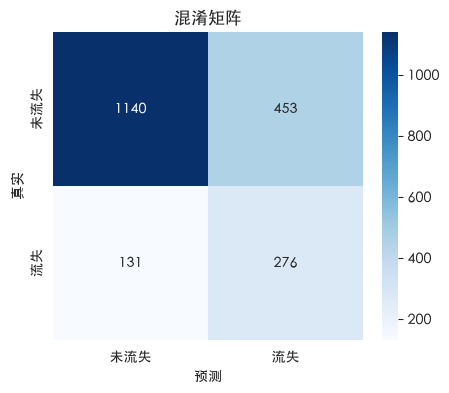

In [20]:
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['未流失', '流失'], yticklabels=['未流失', '流失'])
plt.xlabel('预测')
plt.ylabel('真实')
plt.title('混淆矩阵')
plt.show()

# 阈值调优

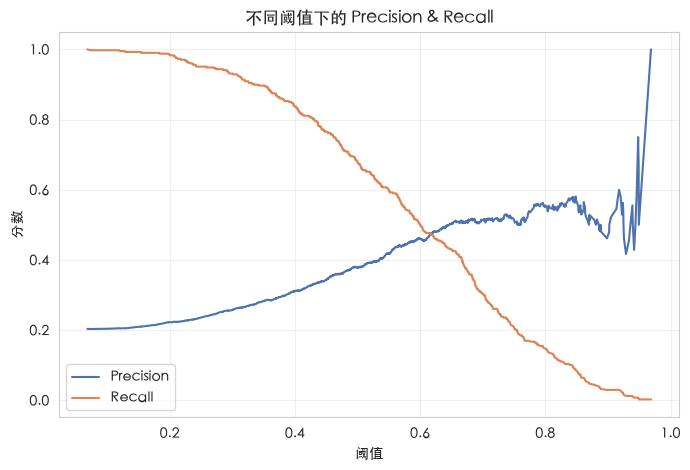

In [21]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_best)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision', color='#4C72B0')
plt.plot(thresholds, recalls[:-1], label='Recall', color='#DD8452')
plt.xlabel('阈值')
plt.ylabel('分数')
plt.title('不同阈值下的 Precision & Recall')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [22]:
for threshold in [0.3, 0.4, 0.5, 0.6]:
    y_pred_thresh = (y_proba_best >= threshold).astype(int)
    print(f"\n阈值 = {threshold}")
    print(f"  召回率(流失): {recall_score(y_test, y_pred_thresh):.3f}")
    print(f"  精确率(流失): {precision_score(y_test, y_pred_thresh):.3f}")
    print(f"  F1(流失):    {f1_score(y_test, y_pred_thresh):.3f}")


阈值 = 0.3
  召回率(流失): 0.931
  精确率(流失): 0.258
  F1(流失):    0.404

阈值 = 0.4
  召回率(流失): 0.838
  精确率(流失): 0.311
  F1(流失):    0.453

阈值 = 0.5
  召回率(流失): 0.678
  精确率(流失): 0.379
  F1(流失):    0.486

阈值 = 0.6
  召回率(流失): 0.499
  精确率(流失): 0.460
  F1(流失):    0.479


In [23]:
f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"全局最优阈值：{best_threshold:.3f}")
print(f"对应的最大F1：{best_f1:.3f}")

全局最优阈值：0.562
对应的最大F1：0.502


# ROC 曲线对比（三个模型）

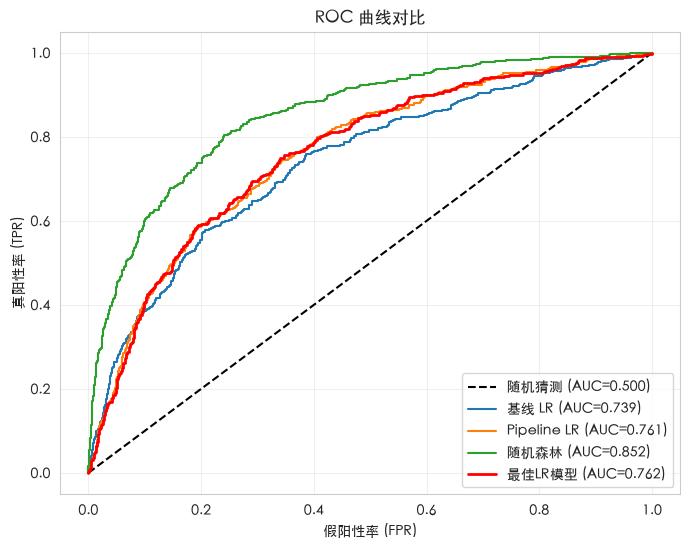

In [24]:
plt.figure(figsize=(8, 6))

# 随机猜测
plt.plot([0, 1], [0, 1], 'k--', label='随机猜测 (AUC=0.500)')

# 基线
fpr, tpr, _ = roc_curve(y_test, y_proba_base)
plt.plot(fpr, tpr, label=f'基线 LR (AUC={roc_auc_score(y_test, y_proba_base):.3f})')

# Pipeline + 标准化
fpr, tpr, _ = roc_curve(y_test, y_proba_lr)
plt.plot(fpr, tpr, label=f'Pipeline LR (AUC={roc_auc_score(y_test, y_proba_lr):.3f})')

# 随机森林
fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
plt.plot(fpr, tpr, label=f'随机森林 (AUC={roc_auc_score(y_test, y_proba_rf):.3f})')

# 调参后最佳LR
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
plt.plot(fpr, tpr, label=f'最佳LR模型 (AUC={roc_auc_score(y_test, y_proba_best):.3f})',
         linewidth=2, color='red')

plt.xlabel('假阳性率 (FPR)')
plt.ylabel('真阳性率 (TPR)')
plt.title('ROC 曲线对比')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# 特征重要性（使用随机森林）

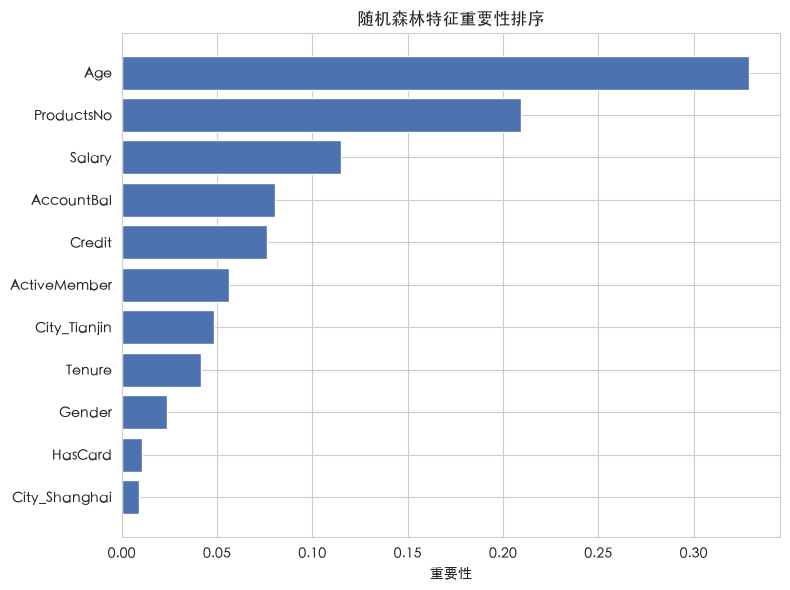

In [25]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(importance_df['feature'], importance_df['importance'], color='#4C72B0')
plt.xlabel('重要性')
plt.title('随机森林特征重要性排序')
plt.tight_layout()
plt.show()

# 逻辑回归方法结果总结

In [26]:
results = {
    '基线（不处理）': (y_proba_base, y_pred_base),
    'class_weight="balanced"': (y_proba_lr, y_pred_lr),
    '调参后 class_weight': (y_proba_best, y_pred_best),
    '随机森林': (y_proba_rf, y_pred_rf),
}

summary = []
for name, (proba, pred) in results.items():
    summary.append({
        '方法': name,
        'AUC': round(roc_auc_score(y_test, proba), 4),
        '准确率': round(accuracy_score(y_test, pred), 4),
        '流失类精确率': round(precision_score(y_test, pred), 4),
        '流失类召回率': round(recall_score(y_test, pred), 4),
        '流失类 F1': round(f1_score(y_test, pred), 4),
    })

summary_df = pd.DataFrame(summary).sort_values('AUC', ascending=False)
summary_df

,方法,AUC,准确率,流失类精确率,流失类召回率,流失类 F1
3,随机森林,0.8525,0.8315,0.5806,0.6192,0.5993
2,调参后 class_weight,0.7618,0.7080,0.3786,0.6781,0.4859
1,"class_weight=""balanced""",0.7606,0.7090,0.3762,0.6536,0.4776
0,基线（不处理）,0.7391,0.8070,0.5854,0.1769,0.2717


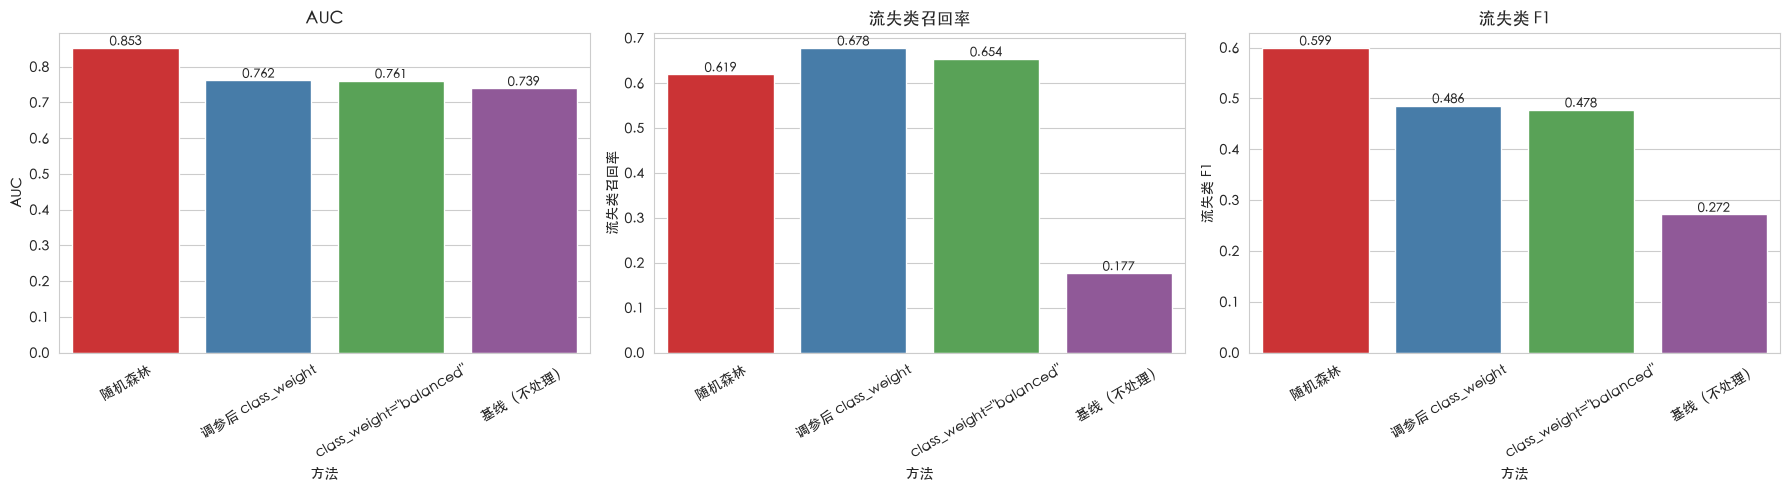

In [27]:
metrics_to_plot = ["AUC", "流失类召回率", "流失类 F1"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, metrics_to_plot):
    sns.barplot(
        x="方法",
        y=metric,
        data=summary_df,
        ax=ax,
        palette="Set1",
        hue="方法",
        legend=False,
    )
    ax.set_title(metric, fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30)
    for p in ax.patches:
        ax.annotate(
            f"{p.get_height():.3f}",
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=9,
        )
plt.tight_layout()
plt.show()

# 逻辑回归最佳模型保存

In [28]:
joblib.dump(best_model, 'churn_model.pkl')
print("模型已保存至 churn_model.pkl")

loaded = joblib.load('churn_model.pkl')
sample_pred = loaded.predict_proba(X_test.iloc[:5])
print("\n前 5 条样本的流失概率:")
print(sample_pred[:, 1])

模型已保存至 churn_model.pkl

前 5 条样本的流失概率:
[0.45285299 0.25241631 0.48198889 0.43745243 0.4157461 ]


## 📊 项目结论

### 主要发现
1. 数据集共 10000 条客户记录，流失率约 20.37%，属于**不平衡分类问题**
2. 使用 `test_size=0.2 + stratify` 保证训练/测试集分布一致
3. 通过 `Pipeline + StandardScaler` 避免数据泄漏
4. 通过 `class_weight='balanced'` 处理类别不平衡

### 模型对比
| 模型 | AUC |
|------|-----|
| 基线 LR | 0.739 |
| Pipeline LR | 0.761 |
| 随机森林 | 0.852 |
| 调参后最佳LR | 0.762 |


## 选择调参后最佳逻辑回归模型的原因：
- 逻辑回归：线性模型，可以直接输出每个特征的系数coef_，知道每一个特征正向 / 负向多大程度影响客户流失概率。
- 随机森林：黑盒树集成模型，只能拿到特征重要性，但没有特征和预测概率之间的线性方向与量化关系；
- 参后的逻辑回归取得更高的流失客户召回率（0.678），在识别潜在流失样本上更有优势。
  
### 关键特征
- `Age`是最重要的

### 业务建议
- 对 **ActiveMember=0**（非活跃用户）客户重点挽留
- 对 **老年客户**、**产品数少的客户**提前干预
- 结合阈值调优，将流失预警的召回率提升到 60%+